# Phishing E-posta Tespiti — Makine Öğrenmesi Demosu

Bu notebook, **phishing (oltalama) e-postalarının** makine öğrenmesi ile nasıl
tespit edilebileceğini **adım adım** göstermek için hazırlanmıştır.

### Bu notebook'ta iki veri seti kullanıyoruz

1. **Ana veri seti — gerçek e-posta metinleri** (`CEAS_08`): E-postanın konusu ve
   gövdesini içerir. Asıl modelimizi (TF-IDF + Logistic Regression) bununla kuracağız.
2. **Karşılaştırma veri seti — sayısal özellikler** (`ethancratchley/email-phishing-dataset`):
   E-postaların ham metnini değil, önceden çıkarılmış 8 sayısal özelliğini içerir
   (kelime sayısı, link sayısı, aciliyet kelimesi sayısı...). Bunu, en sonda
   "özellik mühendisliği" karşılaştırması için kullanacağız.


> **Not:** İkinci veri setinde ham metin yoktur. Bu yüzden tokenization / TF-IDF
> gibi metin işlemleri onun üzerinde yapılamaz. Ders açısından bu farkın kendisi
> güzel bir öğrenme fırsatıdır: "aynı problemi iki farklı veri temsili ile çözmek".

---

## 0. Kurulum

In [31]:
import warnings
warnings.filterwarnings("ignore")   

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_SEED = 42
print("Kütüphaneler hazır ✅")

Kütüphaneler hazır ✅


## 1. Phishing Nedir?

### Spam nedir?
**Spam**, istenmeyen toplu e-postalardır. Genellikle reklam amaçlıdır (ilaç,
indirim, ürün tanıtımı...). Rahatsız edicidir ama çoğu zaman doğrudan tehlikeli
değildir.

### Phishing (oltalama) nedir?
**Phishing**, kullanıcıyı **kandırarak** hassas bilgilerini (şifre, kredi kartı,
banka bilgisi) çalmayı hedefleyen sahte e-postalardır. Saldırgan genellikle
güvenilir bir kurum (banka, kargo şirketi, e-posta sağlayıcısı) gibi davranır.

### İkisi arasındaki fark

| | Spam | Phishing |
|---|---|---|
| **Amaç** | Reklam / tanıtım | Bilgi çalmak, dolandırmak |
| **Tehlike** | Genelde düşük | **Yüksek** |
| **Yöntem** | Toplu gönderim | Taklit + aciliyet + sahte link |




### Gerçek hayatta neden tehlikeli?
- Sahte "banka" sayfasına şifrenizi girersiniz → hesabınız boşaltılır.
- Kurumsal bir çalışan kandırılırsa → **tüm şirket** sızıntıya uğrayabilir.
- Fidye yazılımlarının en yaygın giriş kapısı phishing e-postalarıdır.

### Makine öğrenmesi bunu neden çözebilir?
Phishing e-postalarında **tekrar eden desenler** vardır: aciliyet ifadeleri
("hemen doğrula", "hesabınız askıya alındı"), şüpheli linkler, taklit kurum
isimleri, dilbilgisi hataları... Bu desenler tek tek kural yazmakla yakalanmaz;
ama makine öğrenmesi modeli, binlerce örnekten bu desenleri **kendisi öğrenir**.

---

## 2. Veri Setini Yükle (gerçek e-posta metinleri)

Ana veri setimiz gerçek e-postaların **konu (subject)** ve **gövde (body)**
metnini içerir. KaggleHub üzerinden yüklüyoruz.

In [32]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "naserabdullahalam/phishing-email-dataset",
    "CEAS_08.csv",
)

print("Satır ve sütun sayısı:", df.shape)
df.head()

Satır ve sütun sayısı: (39154, 7)


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    39154 non-null  str  
 1   receiver  38692 non-null  str  
 2   date      39154 non-null  str  
 3   subject   39126 non-null  str  
 4   body      39154 non-null  str  
 5   label     39154 non-null  int64
 6   urls      39154 non-null  int64
dtypes: int64(2), str(5)
memory usage: 2.1 MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sender,39154,24578,qydlqcws-iacfym@issues.apache.org,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
receiver,38692,3693,user6@gvc.ceas-challenge.cc,1375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,39154,38658,"Thu, 07 Aug 2008 21:38:18 -0100",8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,39126,15436,CNN.com Daily Top 10,2930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,39154,39154,"Buck up, your troubles caused by small dimensi...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,39154.0,NaN,NaN,NaN,0.557848,0.496649,0.0,0.0,1.0,1.0,1.0
urls,39154.0,NaN,NaN,NaN,0.66997,0.47023,0.0,0.0,1.0,1.0,1.0


In [5]:
df.columns

Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='str')

### Sütunların anlamı

| Sütun | Anlamı |
|---|---|
| `sender` | Gönderen e-posta adresi |
| `receiver` | Alıcı e-posta adresi |
| `date` | Gönderim tarihi |
| `subject` | E-postanın **konu** satırı |
| `body` | E-postanın **gövde** metni (asıl içerik) |
| `urls` | E-postada link olup olmadığı (1/0) |
| `label` | **Hedef değişkenimiz**: `1 = Phishing`, `0 = Güvenli (normal)` |

Bizim için en önemli sütunlar **`subject`**, **`body`** (girdi) ve **`label`**
(çıktı / tahmin etmek istediğimiz şey).

## 3. Veri Analizi (EDA — Exploratory Data Analysis)

In [33]:
# BOŞLUK SİLME
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

# KONU + GÖVDE BİRLEŞİMİ
df["text"] = (df["subject"] + " " + df["body"]).str.strip()

# ETİKET ENCODING
df["label_name"] = df["label"].map({0: "Güvenli", 1: "Phishing"})
df[["subject", "label", "label_name"]].head()

,subject,label,label_name
0,Never agree to be a loser,1,Phishing
1,Befriend Jenna Jameson,1,Phishing
2,CNN.com Daily Top 10,1,Phishing
3,Re: svn commit: r619753 - in /spamassassin/tru...,0,Güvenli
4,SpecialPricesPharmMoreinfo,1,Phishing


### 3.1 Sınıf dağılımı (phishing / normal oranı)

label_name
Phishing    21842
Güvenli     17312
Name: count, dtype: int64

Phishing oranı: %55.8


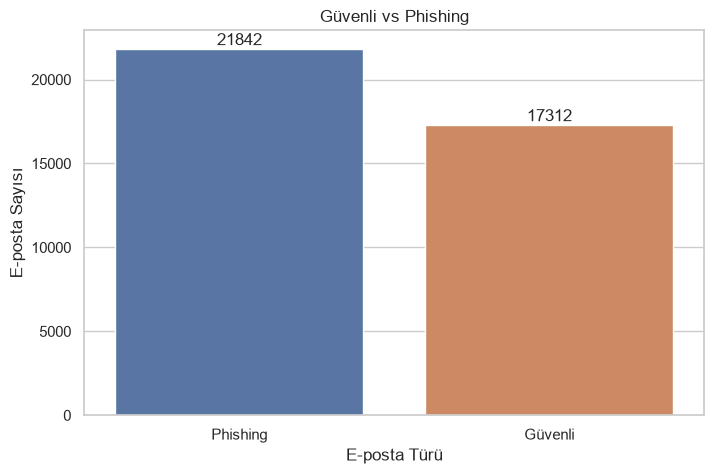

In [35]:
counts = df["label_name"].value_counts()
print(counts)
print("\nPhishing oranı: %{:.1f}".format(100 * df["label"].mean()))

plt.figure()
ax = sns.countplot(data=df, x="label_name", palette=["#4C72B0", "#DD8452"])
ax.set_title("Güvenli vs Phishing")
ax.set_xlabel("E-posta Türü")
ax.set_ylabel("E-posta Sayısı")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

Bu veri seti **dengeli** sayılır (phishing ve güvenli sayıları birbirine yakın).
Bu iyi bir haber: dengesiz veri setlerinde model çoğunluk sınıfını ezberleyebilir.

### 3.2 Eksik veri analizi

In [8]:
missing = df.isnull().sum()
print("Sütun bazında eksik değer sayısı:\n")
print(missing)

Sütun bazında eksik değer sayısı:

sender          0
receiver      462
date            0
subject         0
body            0
label           0
urls            0
text            0
label_name      0
dtype: int64


### 3.3 E-posta uzunluğu

In [36]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

print("Ortalama karakter sayısı: {:.0f}".format(df["char_count"].mean()))
print("Ortalama kelime sayısı  : {:.0f}".format(df["word_count"].mean()))
print()
print("En UZUN e-posta : {} kelime".format(df["word_count"].max()))
print("En KISA e-posta : {} kelime".format(df["word_count"].min()))

Ortalama karakter sayısı: 1608
Ortalama kelime sayısı  : 208

En UZUN e-posta : 19873 kelime
En KISA e-posta : 2 kelime


In [37]:
en_uzun = df.loc[df["word_count"].idxmax()]
en_kisa = df.loc[df["word_count"].idxmin()]

print("── EN UZUN E-POSTA ({} kelime, {}) ──".format(en_uzun["word_count"], en_uzun["label_name"]))
print(en_uzun["text"][:300], "...\n")
print("── EN KISA E-POSTA ({} kelime, {}) ──".format(en_kisa["word_count"], en_kisa["label_name"]))
print(repr(en_kisa["text"][:300]))

── EN UZUN E-POSTA (19873 kelime, Güvenli) ──
Buzz Alert! Ten things the cool kids are talking about WhatIs.com February 12, 2008 Published by  WhatIs.com THIS ISSUE:   > Buzz Alert!:   What people were talking about while you were working   > In case you missed it:   Because we know you're busy! BUZZ ALERT! ultra wideband   How and why Bluetoo ...

── EN KISA E-POSTA (2 kelime, Güvenli) ──
'unsubscribe Unsubscribe'


### 3.4 Kelime sayısı dağılımı

E-postaların çoğu kısa, birkaç tanesi çok uzun. Bu tür dağılımlarda uç değerleri
(outlier) kırpıp bakmak grafiği daha okunur yapar.

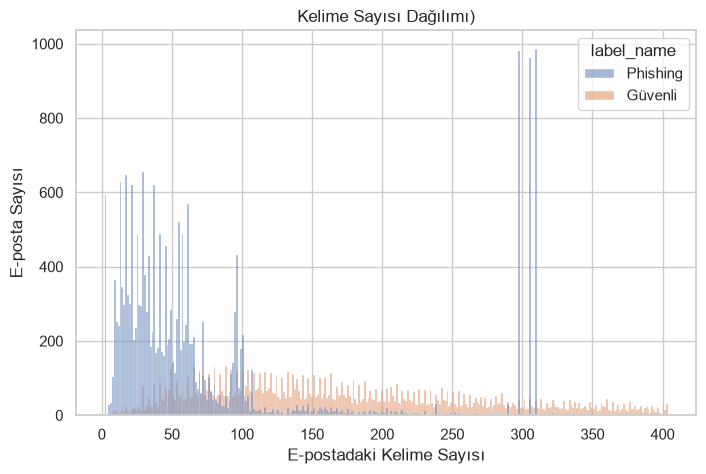

In [47]:
ust_sinir = df["word_count"].quantile(0.90)

plt.figure()
ax = sns.histplot(
    data=df[df["word_count"] <= ust_sinir],
    x="word_count", hue="label_name", bins=300, palette=["#4C72B0", "#DD8452"],
)
ax.set_title("Kelime Sayısı Dağılımı)")
ax.set_xlabel("E-postadaki Kelime Sayısı")
ax.set_ylabel("E-posta Sayısı")
plt.show()

## 4. Gerçek E-posta Örnekleri

Şimdi veri setinden **rastgele** 5 güvenli ve 5 phishing e-posta seçip deneyelim.

In [12]:
def ornekleri_goster(veri, etiket_adi, adet=5):
    ornekler = veri[veri["label_name"] == etiket_adi].sample(adet, random_state=RANDOM_SEED)
    for _, satir in ornekler.iterrows():
        konu = (satir["subject"] or "(konu yok)").strip()
        govde = satir["body"].strip().replace("\n", " ")
        print("-------------------------")
        print("Label:", etiket_adi)
        print("\nSubject:\n" + konu[:120])
        print("\nBody:\n" + govde[:400] + ("..." if len(govde) > 400 else ""))
        print()

print("===== 5 GÜVENLİ (NORMAL) E-POSTA =====\n")
ornekleri_goster(df, "Güvenli")

===== 5 GÜVENLİ (NORMAL) E-POSTA =====

-------------------------
Label: Güvenli

Subject:
[SM-DEVEL] SubFolders untranslated

Body:
Hi Everybody, my squirrelmail version is  squirrelmail-1.4.13  i can't translate the INBOX.Sent, INBOX.Drafts and INBOX.Trash  found the left frame of the main window.  everything is translated except those words and they are not included in the squirrelmail.pot also. i have tried to include in my translation strings still the result is the same. please please help me.  Thanks in advance,  Helen

-------------------------
Label: Güvenli

Subject:
[Python-3000] PEP 3102 question

Body:
Do I understand correctly that with PEP 3102 implemented, keyword arguments can follow vararg in function definitions, but doing the same when calling the function is still a syntax error?  With the latest py3k,  >>> def f(a, *args, v=None): .    pass . >>> f(a, *args, v=None)   File "", line 1     f(a, *args, v=None)                 ^ SyntaxError: invalid syntax  Is this in

In [13]:
print("===== 5 PHISHING E-POSTA =====\n")
ornekleri_goster(df, "Phishing")

===== 5 PHISHING E-POSTA =====

-------------------------
Label: Phishing

Subject:
The bigger tool

Body:
Dear bbaf0d8f5091008654f086221f7bb1f9  Summer is a exact time to take a break at work and think about your health & personal life.  And we are glad to assist you with it.   From now on till 30th of  October you can use our limited proposal.  Visit our site for further details.  traditionstreet.com  6 Aug 2008 05:05:01

-------------------------
Label: Phishing

Subject:
CNN.com Daily Top 10

Body:
>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug  1, 2008  3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= TOP 10 VIDEOS 1. PARIS HILTON TAKES ON MCCAIN http://www.cnn.com/video/partners/email/index.html?url=/video/politics/2008/08/06/wynter.paris.hilton.ad.cnn Paris Hilton swings back at Repu...

-------------------------
Label: Phishing

Subject:
Satisfy your woman?s craving easily

### Yorum

Phishing örneklerinde tipik olarak şunları görürüz:
- **Aciliyet hissi:** "hemen", "hesabınız askıya alındı", "24 saat içinde".
- **Sahte linkler:** gerçek kuruma benzeyen ama farklı alan adları.
- **Kişisel bilgi talebi:** şifre, hesap doğrulama, ödeme bilgisi.
- **Dilbilgisi/yazım hataları** ve genel "kurumsal olmayan" ton.

Güvenli e-postalar ise genellikle **bilgilendirici**, belirli bir bağlamı olan
ve kişisel bilgi istemeyen mesajlardır. Örneğin:

> *"Bu, ekibin haftalık bilgilendirme mailidir; kullanıcıdan hiçbir gizli bilgi
> istememektedir."*

vs.

> *"Bu e-posta, kullanıcıda aciliyet hissi yaratıp onu sahte bir linke tıklamaya
> yönlendirmeye çalışıyor."*

---

## 5. Phishing Belirtileri (Anahtar Kelimeler)

Sezgimiz şu: phishing e-postalarında bazı kelimeler (verify, account, password,
urgent, click, login, bank...) **daha sık** geçer. Bunu veriyle doğrulayalım.

In [14]:
# İncelemek istediğimiz belirti kelimeleri
belirti_kelimeleri = [
    "http", "https", "verify", "account", "password",
    "urgent", "click", "login", "bank", "update",
]

# Her kelimenin phishing ve güvenli e-postalarda kaç kez GEÇTİĞİ e-postayı sayalım
metin_lower = df["text"].str.lower()

satirlar = []
for kelime in belirti_kelimeleri:
    icerir = metin_lower.str.contains(kelime, regex=False)
    phishing_orani = df.loc[icerir, "label"].mean() * 100 if icerir.any() else 0
    satirlar.append({
        "kelime": kelime,
        "phishing_mailde": int(((df["label"] == 1) & icerir).sum()),
        "guvenli_mailde":  int(((df["label"] == 0) & icerir).sum()),
    })

belirti_df = pd.DataFrame(satirlar).set_index("kelime")
belirti_df

,phishing_mailde,guvenli_mailde
kelime,,
http,14891,11387
https,1,1186
verify,5,239
account,314,1100
password,11,423
urgent,80,55
click,2917,1560
login,11,320
bank,89,240


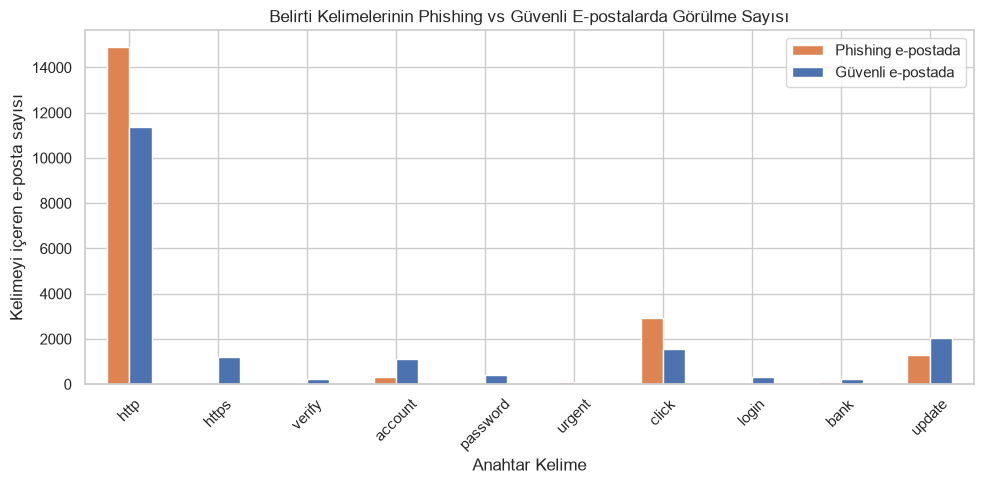

In [15]:
# Grafikle karşılaştıralım
ax = belirti_df.plot(kind="bar", figsize=(10, 5), color=["#DD8452", "#4C72B0"])
ax.set_title("Belirti Kelimelerinin Phishing vs Güvenli E-postalarda Görülme Sayısı")
ax.set_xlabel("Anahtar Kelime")
ax.set_ylabel("Kelimeyi içeren e-posta sayısı")
ax.legend(["Phishing e-postada", "Güvenli e-postada"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Grafikte bazı kelimelerin (örneğin *click*, *hhtp*, *update*) phishing
e-postalarda belirgin şekilde daha sık geçtiğini görebiliriz. İşte modelimiz de
tam olarak bu tür ipuçlarını — ama **yüzlerce kelime için aynı anda** — öğrenecek.

---

## 6. Veri Ön İşleme

Makine öğrenmesi modeli ham metni **anlamaz**; sayılara ihtiyaç duyar. Metni
sayısal bir forma çevirmeden önce onu temizleriz. Aşağıda her adımı ve **neden**
yaptığımızı açıklıyoruz.

| Adım | Ne yapar? | Neden? |
|---|---|---|
| **Küçük harfe çevirme** | `Bank` → `bank` | "Bank" ve "bank" aynı kelime sayılsın |
| **Link temizleme** | `http://...` → kaldırılır | Uzun URL'ler gürültü yaratır; varlığı önemli, içeriği değil |
| **Noktalama temizleme** | `!,.?` kaldırılır | Kelimeye odaklanmak için |
| **Fazla boşluk temizleme** | çok boşluk → tek boşluk | Düzgün tokenization için |
| **Tokenization** | metin → kelime listesi | Modelin "birim"i kelimedir |
| **Stop words** | `the, is, and`... çıkarılır | Bu kelimeler ayırt edici değil |
| **TF-IDF** | kelime → sayısal ağırlık | Az geçen ama ayırt edici kelimeleri öne çıkarır |

### TF-IDF nedir? (kısaca)
**TF-IDF = Term Frequency × Inverse Document Frequency.**
- Bir kelime bir e-postada çok geçiyorsa → önemli olabilir (TF ↑).
- Ama o kelime *her* e-postada geçiyorsa (örn. "the") → ayırt edici değil (IDF ↓).

Yani TF-IDF, "bu e-postaya özgü, ayırt edici kelimeler" e yüksek ağırlık verir.

In [52]:
def temizle(metin):
    metin = metin.lower()                           # 1) küçük harf
    metin = re.sub(r"http\S+|www\.\S+", " ", metin) # 2) linkleri kaldır
    metin = re.sub(r"[^a-z\s]", " ", metin)         # 3) harf olmayanları kaldır
    metin = re.sub(r"\s+", " ", metin).strip()      # 4) fazla boşlukları temizle
    return metin

# Örnek: temizleme öncesi ve sonrası
ornek = df["text"].iloc[10]
print("ÖNCE :", ornek[:160])
print("\nSONRA:", temizle(ornek)[:160])

ÖNCE : debt consolidation  
Do Not consolidate your debt   Eliminate it!

Legally ELIMINATE your creditT card and other unsecured debt

* WITHOUT ever making another p

SONRA: debt consolidation do not consolidate your debt eliminate it legally eliminate your creditt card and other unsecured debt without ever making another payment to


In [53]:
df["clean_text"] = df["text"].apply(temizle)
df[["text", "clean_text"]].head(3)

,text,clean_text
0,"Never agree to be a loser Buck up, your troubl...",never agree to be a loser buck up your trouble...
1,Befriend Jenna Jameson \nUpgrade your sex and ...,befriend jenna jameson upgrade your sex and pl...
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,cnn com daily top the daily top from cnn com t...


> **Tokenization ve stop words'ü ayrıca kodlamıyoruz:** bunları birazdan
> `TfidfVectorizer` bizim için otomatik yapacak (`stop_words="english"` ile stop
> words'leri atacak, metni kelimelere ayıracak). Kütüphanenin hazır ve test edilmiş
> aracını kullanmak, "tekerleği yeniden icat etmekten" daha temiz bir yaklaşımdır.

## 7. Model

- **%80 train**
- **%20 test:**


**Logistic Regression**, ikili sınıflandırma (0/1) için en yaygın ve en anlaşılır algoritmadır. "Bu e-posta phishing mi?" sorusuna **0–1 arası bir olasılık** üretir.
1. **TF-IDF** ile metni sayısal vektöre çevir.
2. Logistic Regression'ı bu vektörlerle eğit.

In [54]:
X = df["clean_text"]   # girdi: temizlenmiş metin
y = df["label"]        # çıktı: 0/1 etiketi

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Eğitim kümesi:", X_train.shape[0], "e-posta")
print("Test kümesi  :", X_test.shape[0], "e-posta")

Eğitim kümesi: 31323 e-posta
Test kümesi  : 7831 e-posta


In [58]:
# 1) Metni sayısala çevir: TF-IDF
vectorizer = TfidfVectorizer(
    stop_words="english",    # İngilizce stop words'leri at
    max_features=5000,       # en sık 5000 kelimeyi kullan (sadelik + hız)
    ngram_range=(1, 2),      # tek kelimeler + ikili kelime grupları
)
X_train_tfidf = vectorizer.fit_transform(X_train)   # eğitimde ÖĞREN + dönüştür
X_test_tfidf = vectorizer.transform(X_test)         # testte SADECE dönüştür

# 2) Modeli eğit
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


print("Model eğitildi")
print("TF-IDF özellik (kelime) sayısı:", len(vectorizer.get_feature_names_out()))

Model eğitildi
TF-IDF özellik (kelime) sayısı: 5000


## 9. Sonuçlar

Modeli test kümesinde değerlendirelim.

In [20]:
# Test kümesinde tahmin
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]   # phishing olasılığı

print("Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
print("Recall   : {:.4f}".format(recall_score(y_test, y_pred)))
print("F1 Score : {:.4f}".format(f1_score(y_test, y_pred)))

Accuracy : 0.9949
Precision: 0.9950
Recall   : 0.9959
F1 Score : 0.9954


### Metrikler ne anlama geliyor?

- **Accuracy (Doğruluk):** Tüm tahminlerin ne kadarı doğru? Basit ama dengesiz
  verilerde yanıltıcı olabilir.
- **Precision (Kesinlik):** "Phishing" dediklerimin ne kadarı **gerçekten**
  phishing? Düşükse → çok sayıda **yanlış alarm** (güvenli maili phishing sanmak).
- **Recall (Duyarlılık):** Gerçek phishinglerin ne kadarını **yakaladım**?
  Düşükse → tehlikeli phishingler **gözden kaçıyor**.
- **F1 Score:** Precision ve Recall'un dengeli ortalaması. Tek bir "genel başarı"
  sayısı isteyince buna bakarız.

> Güvenlikte genellikle **Recall** çok önemlidir: bir phishing'i kaçırmanın
> bedeli, bir güvenli maile yanlışlıkla takılmaktan çok daha ağırdır.

### Classification Report

In [21]:
print(classification_report(y_test, y_pred, target_names=["Güvenli", "Phishing"]))

              precision    recall  f1-score   support

     Güvenli       0.99      0.99      0.99      3462
    Phishing       0.99      1.00      1.00      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



### Confusion Matrix (Karışıklık Matrisi)

Bu matris, modelin **nerede** hata yaptığını gösterir:
- Sol üst / sağ alt → **doğru** tahminler.
- Sağ üst → güvenliyi phishing sandık (yanlış alarm).
- Sol alt → phishing'i kaçırdık (en tehlikeli hata).

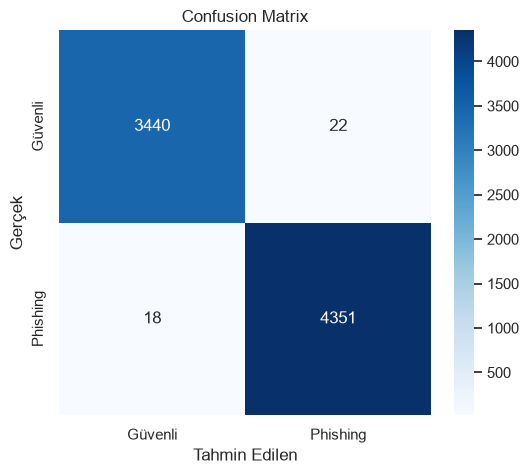

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Güvenli", "Phishing"],
            yticklabels=["Güvenli", "Phishing"])
plt.title("Confusion Matrix")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()

### ROC Curve

**ROC eğrisi**, modelin farklı eşik değerlerinde doğru/yanlış alarm dengesini
gösterir. Eğri sol-üst köşeye ne kadar yakınsa model o kadar iyidir.
**AUC** (eğri altında kalan alan) 1.0'a yaklaştıkça mükemmel demektir; 0.5 ise
rastgele tahmin seviyesidir.

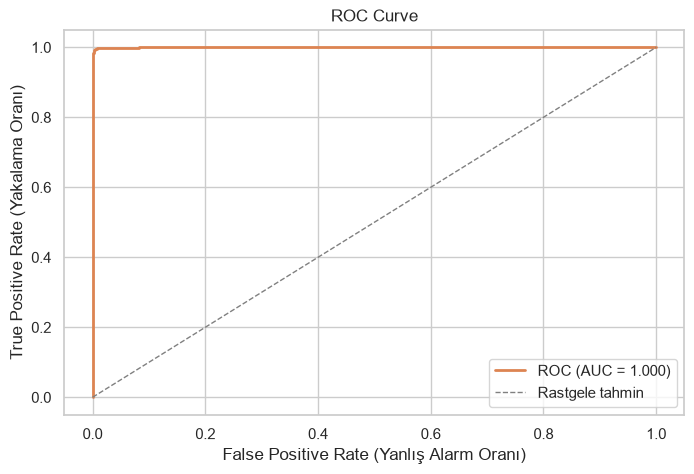

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, color="#DD8452", lw=2, label="ROC (AUC = {:.3f})".format(auc))
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Rastgele tahmin")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate (Yanlış Alarm Oranı)")
plt.ylabel("True Positive Rate (Yakalama Oranı)")
plt.legend(loc="lower right")
plt.show()

## 10. Kendi E-postanı Dene!

Şimdi modeli **canlı** kullanalım. Aşağıdaki `email` değişkenine istediğiniz
metni yazın; model phishing olup olmadığını ve olasılığını söylesin.

In [24]:
def phishing_mi(email_metni):
    temiz = temizle(email_metni)                 # 6. bölümdeki aynı temizleme
    vec = vectorizer.transform([temiz])           # TF-IDF'e çevir
    tahmin = model.predict(vec)[0]                # 0 / 1
    olasilik = model.predict_proba(vec)[0][1]     # phishing olasılığı

    etiket = "Phishing" if tahmin == 1 else "Güvenli"
    print("Prediction\n")
    print(" ", etiket)
    print("\nProbability (phishing): %{:.0f}".format(olasilik * 100))

    # Neden böyle dediğine dair basit bir açıklama: hangi belirti kelimeleri var?
    bulunan = [k for k in belirti_kelimeleri if k in temiz]
    print("\nAçıklama:")
    if tahmin == 1:
        print("  Model bunu phishing olarak işaretledi.")
        if bulunan:
            print("  Dikkat çeken kelimeler:", ", ".join(bulunan))
        print("  Aciliyet + kişisel bilgi/link talebi tipik phishing desenidir.")
    else:
        print("  Model bunu güvenli buldu: tehdit/aciliyet deseni zayıf.")

In [25]:
# ↓↓↓ Buraya istediğiniz e-postayı yazabilirsiniz ↓↓↓
email = """
Dear Customer,

We detected unusual activity on your account. Please verify your account
immediately to avoid suspension. Click the link below and confirm your
password and banking details within 24 hours.

http://secure-verify-login.example.com

Bank Security Team
"""

phishing_mi(email)

Prediction

  Phishing

Probability (phishing): %70

Açıklama:
  Model bunu phishing olarak işaretledi.
  Dikkat çeken kelimeler: verify, account, password, click, bank
  Aciliyet + kişisel bilgi/link talebi tipik phishing desenidir.


In [26]:
# İkinci örnek: normal, güvenli bir e-posta
email_normal = """
Hi team,

Just a reminder that our weekly project sync is tomorrow at 10:00 AM.
The agenda and meeting notes are attached. Let me know if you have anything
to add.

Thanks,
Alex
"""

phishing_mi(email_normal)

Prediction

  Güvenli

Probability (phishing): %7

Açıklama:
  Model bunu güvenli buldu: tehdit/aciliyet deseni zayıf.


İki örnekte de modelin mantıklı kararlar verdiğini görüyoruz: aciliyet + şifre/link
talebi içeren mail **phishing**, sıradan bir toplantı hatırlatması ise **güvenli**.

---

## 11. Bonus — Farklı Bir Yaklaşım: Sayısal Özellikler

Şimdiye kadar e-postanın **ham metnini** (TF-IDF ile) kullandık. Peki ya metni
hiç görmeden, sadece birkaç **sayısal özet** ile çalışsaydık?

Başta bahsettiğimiz ikinci veri seti (`ethancratchley/email-phishing-dataset`)
tam olarak bunu yapıyor: her e-postayı **8 sayı** ile temsil ediyor:
kelime sayısı, link sayısı, aciliyet kelimesi sayısı, yazım hatası sayısı...

**"Feature Engineering"**

In [59]:
df_num = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ethancratchley/email-phishing-dataset",
    "email_phishing_data.csv",
)
print("Boyut:", df_num.shape)
print("Sütunlar:", list(df_num.columns))
df_num.head()

Boyut: (524846, 9)
Sütunlar: ['num_words', 'num_unique_words', 'num_stopwords', 'num_links', 'num_unique_domains', 'num_email_addresses', 'num_spelling_errors', 'num_urgent_keywords', 'label']


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


### 11.1 Phishing'ler hangi özelliklerde farklılaşıyor?

Her özelliğin phishing ve güvenli e-postalardaki **ortalamasını** karşılaştıralım.

                     Güvenli (0)  Phishing (1)
num_words                 276.63        246.15
num_unique_words          122.94        128.30
num_stopwords              80.10         75.71
num_links                   0.90          0.42
num_unique_domains          0.35          0.31
num_email_addresses         2.14          0.18
num_spelling_errors        24.77         19.16
num_urgent_keywords         0.24          0.33


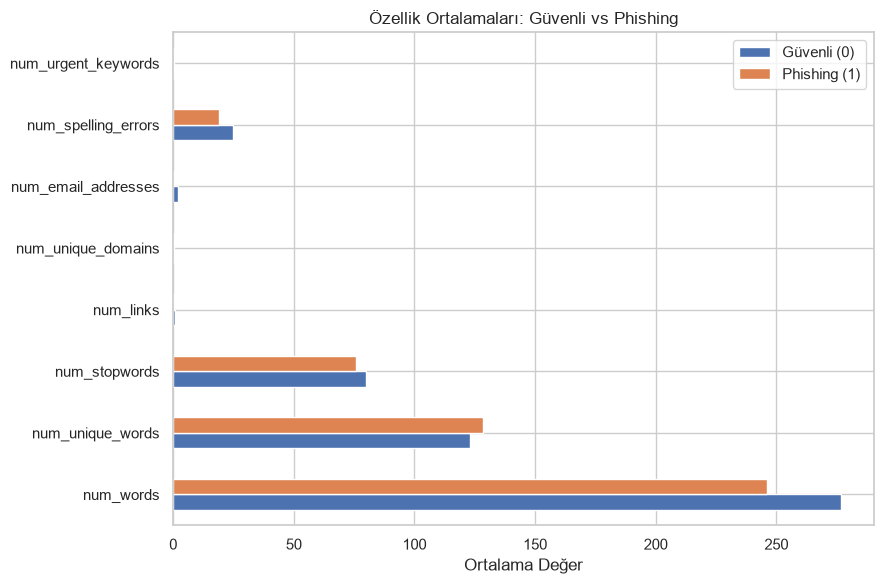

In [28]:
ortalama = df_num.groupby("label").mean().T
ortalama.columns = ["Güvenli (0)", "Phishing (1)"]
print(ortalama.round(2))

ax = ortalama.plot(kind="barh", figsize=(9, 6), color=["#4C72B0", "#DD8452"])
ax.set_title("Özellik Ortalamaları: Güvenli vs Phishing")
ax.set_xlabel("Ortalama Değer")
plt.tight_layout()
plt.show()

Bu 8 sayı, phishing'i ayırt etmekte zayıf çünkü data değerleri birbirine yakın ama deneyeceğiz.

### 11.2 Bu sayısal özelliklerle model

Bu veri seti çok **dengesiz** (phishing sadece ~%1.3). Adil bir karşılaştırma için
sınıfları dengeleyip (eşit sayıda phishing ve güvenli) küçük bir model eğitelim.

In [60]:
# Dengeli alt küme: tüm phishing + eşit sayıda güvenli
phishing_rows = df_num[df_num["label"] == 1]
safe_rows = df_num[df_num["label"] == 0].sample(len(phishing_rows), random_state=RANDOM_SEED)
balanced = pd.concat([phishing_rows, safe_rows]).sample(frac=1, random_state=RANDOM_SEED)

Xn = balanced.drop(columns="label")
yn = balanced["label"]

Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    Xn, yn, test_size=0.20, random_state=RANDOM_SEED, stratify=yn
)

scaler = StandardScaler().fit(Xn_tr)
num_model = LogisticRegression(max_iter=1000).fit(scaler.transform(Xn_tr), yn_tr)

yn_pred = num_model.predict(scaler.transform(Xn_te))
print("SAYISAL ÖZELLİK MODELİ (dengeli):")
print("  Accuracy : {:.3f}".format(accuracy_score(yn_te, yn_pred)))
print("  Precision: {:.3f}".format(precision_score(yn_te, yn_pred)))
print("  Recall   : {:.3f}".format(recall_score(yn_te, yn_pred)))
print("  F1 Score : {:.3f}".format(f1_score(yn_te, yn_pred)))

SAYISAL ÖZELLİK MODELİ (dengeli):
  Accuracy : 0.647
  Precision: 0.620
  Recall   : 0.757
  F1 Score : 0.682


Leş gibi bir sonuç ortaya çıktı, direk ham verilerden (gerçek mailler) ile çalışmak ve model eğitmek bizim için daha başarılıdır.